# Exploratory Analysis: AI-Driven Restructuring of Junior SWE Labor

This notebook explores four datasets to validate our core hypotheses:
- **Kaggle LinkedIn postings (2023–2024):** ~124K postings with titles, descriptions, seniority, skills
- **LinkedIn scraped data (March 2026):** 486 SWE + 181 non-SWE postings from our daily scraper
- **Revelio Labs public data (2021–2026):** Aggregate hiring, attrition, job openings, salaries by occupation (SOC)
- **FRED JOLTS:** Official job openings for Professional & Business Services, Information sector, and Total Nonfarm

---

## Research Questions Addressed
| RQ | Question | What we look for here |
|-----|---------|----------------------|
| RQ1 | Disappearing vs. redefined? | Seniority distribution shifts, description length/complexity changes |
| RQ2 | Which skills migrated? | Skill prevalence in junior vs. senior postings, cross-period comparison |
| RQ3 | Structural break late 2025? | JOLTS + Revelio time series for regime shifts |
| RQ4 | SWE-specific or broader? | Compare SWE occupations vs. controls in Revelio + JOLTS |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA = 'data/'
print('Setup complete.')

Setup complete.


---
## 1. Load & Clean Data

### 1a. Kaggle LinkedIn (2023–2024)

In [2]:
# Load Kaggle LinkedIn postings — large file, use relevant columns only
KAGGLE_COLS = [
    'job_id', 'company_name', 'title', 'description', 'location',
    'formatted_experience_level', 'formatted_work_type', 'skills_desc',
    'original_listed_time', 'listed_time', 'max_salary', 'med_salary',
    'min_salary', 'pay_period', 'remote_allowed', 'views', 'applies'
]

kaggle = pd.read_csv(
    f'{DATA}kaggle-linkedin-jobs-2023-2024/postings.csv',
    usecols=KAGGLE_COLS,
    low_memory=False
)

# Parse dates
kaggle['listed_date'] = pd.to_datetime(kaggle['listed_time'], unit='ms', errors='coerce')
kaggle['listed_month'] = kaggle['listed_date'].dt.to_period('M')

# Standardize seniority
kaggle['seniority'] = kaggle['formatted_experience_level'].str.strip().str.lower()

print(f'Kaggle postings loaded: {len(kaggle):,} rows')
print(f'Date range: {kaggle["listed_date"].min()} to {kaggle["listed_date"].max()}')
print(f'\nSeniority distribution:')
print(kaggle['seniority'].value_counts())

Kaggle postings loaded: 123,849 rows
Date range: 2024-03-24 21:50:14 to 2024-04-20 00:26:56

Seniority distribution:
seniority
mid-senior level    41489
entry level         36708
associate            9826
director             3746
internship           1449
executive            1222
Name: count, dtype: int64


### 1b. Filter to SWE-related postings

In [3]:
# Define SWE-related title patterns
SWE_PATTERN = r'(?i)\b(software\s*(engineer|developer|dev)|swe|full[- ]?stack|front[- ]?end|back[- ]?end|web\s*developer|mobile\s*developer|devops|platform\s*engineer|data\s*engineer|ml\s*engineer|machine\s*learning\s*engineer|site\s*reliability)\b'

# Control occupations (non-AI-exposed) for DiD
CONTROL_PATTERN = r'(?i)\b(civil\s*engineer|mechanical\s*engineer|nurse|registered\s*nurse|nursing|electrical\s*engineer|chemical\s*engineer)\b'

kaggle['is_swe'] = kaggle['title'].str.contains(SWE_PATTERN, na=False)
kaggle['is_control'] = kaggle['title'].str.contains(CONTROL_PATTERN, na=False)

swe = kaggle[kaggle['is_swe']].copy()
control = kaggle[kaggle['is_control']].copy()

print(f'SWE postings: {len(swe):,} ({len(swe)/len(kaggle)*100:.1f}% of total)')
print(f'Control postings: {len(control):,} ({len(control)/len(kaggle)*100:.1f}% of total)')
print(f'\nSWE seniority breakdown:')
print(swe['seniority'].value_counts())

SWE postings: 3,134 (2.5% of total)
Control postings: 6,778 (5.5% of total)

SWE seniority breakdown:
seniority
mid-senior level    1532
entry level          385
associate            141
internship            16
director               8
executive              3
Name: count, dtype: int64


### 1c. LinkedIn Scraped Data (March 2026)

Our daily scraper collected 486 SWE jobs and 181 non-SWE jobs from LinkedIn on 2026-03-05.

In [4]:
# Load today's scraped SWE and non-SWE data
scraped_swe = pd.read_csv(f'{DATA}scraped/2026-03-05_swe_jobs.csv', low_memory=False)
scraped_non_swe = pd.read_csv(f'{DATA}scraped/2026-03-05_non_swe_jobs.csv', low_memory=False)

# Combine for full scraped dataset
scraped = pd.concat([scraped_swe, scraped_non_swe], ignore_index=True)

# LinkedIn's original label
scraped['seniority_linkedin'] = scraped['job_level'].str.strip().str.lower()
scraped['listed_date'] = pd.to_datetime(scraped['date_posted'], errors='coerce')
scraped['is_swe'] = scraped.index < len(scraped_swe)  # SWE file came first

print(f'Scraped data loaded: {len(scraped):,} total rows')
print(f'  SWE postings: {scraped["is_swe"].sum():,}')
print(f'  Non-SWE (control): {(~scraped["is_swe"]).sum():,}')
print(f'\nLinkedIn seniority labels (raw):')
print(scraped[scraped['is_swe']]['seniority_linkedin'].value_counts())
print(f'\n"not applicable" rate: {(scraped[scraped["is_swe"]]["seniority_linkedin"] == "not applicable").mean():.0%}')

Scraped data loaded: 667 total rows
  SWE postings: 486
  Non-SWE (control): 181

LinkedIn seniority labels (raw):
seniority_linkedin
mid-senior level    215
not applicable      131
entry level         120
internship            9
associate             7
executive             2
director              2
Name: count, dtype: int64

"not applicable" rate: 27%


### 1d. Impute Seniority for Unlabeled Postings

27% of scraped SWE postings have `job_level = "not applicable"`. We build a rule-based
classifier using **title keywords** (primary) and **description experience requirements** (fallback):

| Signal | Source | Maps to |
|--------|--------|---------|
| Senior, Sr., Staff, Principal, Lead | Title | mid-senior level |
| III, 3, IV, 4+ | Title | mid-senior level |
| II, 2 | Title | associate |
| Junior, Jr., New Grad, Early Career, I, 1 | Title | entry level |
| Intern | Title | internship |
| Manager, Director, VP, Head of | Title | director |
| 0–2 years required | Description | entry level |
| 3–4 years required | Description | associate |
| 5+ years required | Description | mid-senior level |

We apply this to **all** scraped postings and validate against LinkedIn's own labels where available.

In [5]:
def impute_seniority(title, description):
    """Classify seniority from title keywords and description experience requirements.
    
    Priority: title keywords > description years > unknown.
    """
    title = str(title).lower().strip()
    desc = str(description).lower()
    
    # --- Title-based rules (highest priority) ---
    # Internship
    if re.search(r'\b(intern|internship)\b', title):
        return 'internship'
    
    # Director+
    if re.search(r'\b(director|vp|vice\s*president|head\s+of|chief)\b', title):
        return 'director'
    
    # Senior / Staff / Principal / Lead / Architect
    if re.search(r'\b(senior|sr\.?|staff|principal|distinguished|lead\b|architect)\b', title):
        return 'mid-senior level'
    
    # Roman numeral / numeric levels in title
    # III, IV, 3, 4+ → mid-senior
    if re.search(r'\biii\b|\biv\b|\b[3-9]\b', title) and re.search(r'engineer|developer|swe', title):
        return 'mid-senior level'
    # II, 2 → associate
    if re.search(r'\bii\b|\b2\b', title) and re.search(r'engineer|developer|swe', title):
        return 'associate'
    # I, 1 → entry (but careful: "I" is also a pronoun, require context)
    if re.search(r'(?:engineer|developer|swe)\s+i\b|\b1\b.*(?:engineer|developer)', title):
        return 'entry level'
    
    # Junior / New Grad / Early Career
    if re.search(r'\b(junior|jr\.?|new\s*grad|entry[- ]?level|early\s*career|associate)\b', title):
        return 'entry level'
    
    # --- Description-based fallback (extract minimum years required) ---
    # Find all "X+ years of experience" patterns and use the minimum mentioned
    year_matches = re.findall(r'(\d+)\+?\s*(?:years?|yrs?)\s*(?:of\s+)?(?:experience|professional|relevant|related|work)', desc)
    reasonable = [int(y) for y in year_matches if 0 < int(y) <= 20]
    if reasonable:
        min_years = min(reasonable)
        if min_years <= 2:
            return 'entry level'
        elif min_years <= 4:
            return 'associate'
        else:
            return 'mid-senior level'
    
    # Broader year pattern (just "X years" without "experience")
    year_matches_broad = re.findall(r'(\d+)\+?\s*years?', desc)
    reasonable_broad = [int(y) for y in year_matches_broad if 0 < int(y) <= 20]
    if reasonable_broad:
        min_years = min(reasonable_broad)
        if min_years <= 2:
            return 'entry level'
        elif min_years <= 4:
            return 'associate'
        else:
            return 'mid-senior level'
    
    return 'unknown'

# Apply to all scraped data
scraped['seniority_imputed'] = scraped.apply(
    lambda row: impute_seniority(row['title'], row['description']), axis=1
)

# Use LinkedIn label when available, imputed for "not applicable"
scraped['seniority'] = scraped['seniority_linkedin'].where(
    scraped['seniority_linkedin'] != 'not applicable',
    scraped['seniority_imputed']
)

swe_2026 = scraped[scraped['is_swe']].copy()
control_2026 = scraped[~scraped['is_swe']].copy()

print('=== Seniority imputation results (SWE only) ===')
print(f'\nBefore (LinkedIn labels):')
print(scraped[scraped['is_swe']]['seniority_linkedin'].value_counts().to_string())
print(f'\nImputed values for "not applicable" postings:')
na_mask = scraped['is_swe'] & (scraped['seniority_linkedin'] == 'not applicable')
print(scraped.loc[na_mask, 'seniority_imputed'].value_counts().to_string())
print(f'\nAfter (combined):')
print(swe_2026['seniority'].value_counts().to_string())
print(f'\nRemaining unknown: {(swe_2026["seniority"] == "unknown").sum()} ({(swe_2026["seniority"] == "unknown").mean():.0%})')

=== Seniority imputation results (SWE only) ===

Before (LinkedIn labels):
seniority_linkedin
mid-senior level    215
not applicable      131
entry level         120
internship            9
associate             7
executive             2
director              2

Imputed values for "not applicable" postings:
seniority_imputed
mid-senior level    57
unknown             41
associate           15
entry level         15
internship           2
director             1

After (combined):
seniority
mid-senior level    272
entry level         135
unknown              41
associate            22
internship           11
director              3
executive             2

Remaining unknown: 41 (8%)


In [6]:
# Validate: how well does our imputed seniority match LinkedIn's own label?
# Use labeled postings (where LinkedIn gave a real seniority) as ground truth

labeled = scraped[
    scraped['is_swe'] & 
    (scraped['seniority_linkedin'] != 'not applicable')
].copy()

labeled['imputed'] = labeled.apply(
    lambda row: impute_seniority(row['title'], row['description']), axis=1
)

# Map to 3-level for cleaner comparison
def to_3level(s):
    if s in ('entry level', 'internship'):
        return 'junior'
    elif s in ('associate',):
        return 'mid'
    elif s in ('mid-senior level', 'director', 'executive'):
        return 'senior'
    return 'other'

labeled['truth_3'] = labeled['seniority_linkedin'].map(to_3level)
labeled['imputed_3'] = labeled['imputed'].map(to_3level)

# Confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
valid = labeled[labeled['imputed_3'] != 'other']  # exclude unknowns

print(f'Validation set: {len(labeled)} labeled SWE postings')
print(f'Classifier produced a label for: {len(valid)}/{len(labeled)} ({len(valid)/len(labeled):.0%})')
print()

if len(valid) > 10:
    print('=== Confusion Matrix (rows=LinkedIn truth, cols=imputed) ===')
    labels = ['junior', 'mid', 'senior']
    cm = confusion_matrix(valid['truth_3'], valid['imputed_3'], labels=labels)
    cm_df = pd.DataFrame(cm, index=[f'True: {l}' for l in labels], columns=[f'Pred: {l}' for l in labels])
    print(cm_df.to_string())
    print()
    print('=== Classification Report ===')
    print(classification_report(valid['truth_3'], valid['imputed_3'], labels=labels, zero_division=0))
    
    # Overall accuracy
    accuracy = (valid['truth_3'] == valid['imputed_3']).mean()
    print(f'Overall accuracy: {accuracy:.1%}')
    
    # Where does it disagree?
    disagree = valid[valid['truth_3'] != valid['imputed_3']]
    if len(disagree) > 0:
        print(f'\nDisagreements ({len(disagree)}):')
        for _, row in disagree.head(10).iterrows():
            print(f'  Title: "{row["title"][:60]}" | LinkedIn: {row["seniority_linkedin"]} | Imputed: {row["imputed"]}')

Validation set: 355 labeled SWE postings
Classifier produced a label for: 227/355 (64%)

=== Confusion Matrix (rows=LinkedIn truth, cols=imputed) ===
              Pred: junior  Pred: mid  Pred: senior
True: junior            17          4            55
True: mid                0          1             3
True: senior            11         19           117

=== Classification Report ===
              precision    recall  f1-score   support

      junior       0.61      0.22      0.33        76
         mid       0.04      0.25      0.07         4
      senior       0.67      0.80      0.73       147

    accuracy                           0.59       227
   macro avg       0.44      0.42      0.38       227
weighted avg       0.64      0.59      0.58       227

Overall accuracy: 59.5%

Disagreements (92):
  Title: "Software Engineer" | LinkedIn: mid-senior level | Imputed: associate
  Title: "Entry-level Software Engineer" | LinkedIn: mid-senior level | Imputed: entry level
  Title: "Sof

### 1d. Revelio Labs Aggregate Data

In [7]:
# Load key Revelio files
rev_openings_occ = pd.read_csv(f'{DATA}revelio/revelio-job-openings-feb-2026/postings_by_occupation.csv')
rev_hiring_occ = pd.read_csv(f'{DATA}revelio/revelio-hiring-attrition-feb-2026/hiring_and_attrition_by_occupation.csv')
rev_salary_soc = pd.read_csv(f'{DATA}revelio/revelio-salaries-feb-2026/salaries_soc.csv')
rev_employment_soc = pd.read_csv(f'{DATA}revelio/revelio-employment-feb-2026/employment_soc.csv')
rev_layoffs = pd.read_csv(f'{DATA}revelio/revelio-layoff-feb-2026/total_layoffs.csv')

# Parse months
for df in [rev_openings_occ, rev_hiring_occ, rev_salary_soc, rev_employment_soc, rev_layoffs]:
    df['month'] = pd.to_datetime(df['month'])

print('Revelio datasets loaded:')
print(f'  Job openings by occupation: {len(rev_openings_occ):,} rows, {rev_openings_occ["month"].min()} to {rev_openings_occ["month"].max()}')
print(f'  Hiring/attrition by occupation: {len(rev_hiring_occ):,} rows')
print(f'  Salaries by SOC: {len(rev_salary_soc):,} rows')
print(f'  Employment by SOC: {len(rev_employment_soc):,} rows')
print(f'  Layoffs (total): {len(rev_layoffs):,} rows')

print(f'\nSOC codes available in openings data:')
print(rev_openings_occ[['soc2d_code', 'soc2d_name']].drop_duplicates().sort_values('soc2d_code').to_string(index=False))

Revelio datasets loaded:
  Job openings by occupation: 1,200 rows, 2022-01-01 00:00:00 to 2026-02-01 00:00:00
  Hiring/attrition by occupation: 1,364 rows
  Salaries by SOC: 1,150 rows
  Employment by SOC: 1,364 rows
  Layoffs (total): 62 rows

SOC codes available in openings data:
 soc2d_code                                     soc2d_name
          0                                  Unknown/Other
         11                                     Management
         13              Business and Financial Operations
         15                      Computer and Mathematical
         17                   Architecture and Engineering
         19             Life, Physical, and Social Science
         21                   Community and Social Service
         23                                          Legal
         25            Educational Instruction and Library
         27 Arts, Design, Entertainment, Sports, and Media
         29         Healthcare Practitioners and Technical
         

### 1e. FRED JOLTS Data (via API)

In [8]:
# Download JOLTS series from FRED
# Key series:
#   JTSJOL      - Total Nonfarm job openings (SA)
#   JTS540099JOL - Professional & Business Services job openings (SA)
#   JTU5100JOL  - Information sector job openings (NSA)
#   JTS7200JOL  - Accommodation & Food Services (SA) — low-AI-exposure control
#   JTS9000JOL  - Government job openings (SA) — another control

FRED_SERIES = {
    'JTSJOL': 'Total Nonfarm',
    'JTS540099JOL': 'Professional & Business Services',
    'JTU5100JOL': 'Information',
    'JTS510099JOL': 'Information (SA)',
    'JTS7200JOL': 'Accommodation & Food Services',
    'JTS9000JOL': 'Government',
    'JTS3000JOL': 'Manufacturing',
    'JTS6000JOL': 'Education & Health Services',
    'JTS4000JOL': 'Trade, Transportation & Utilities',
}

def fetch_fred_csv(series_id):
    """Fetch a FRED series as CSV (no API key needed for CSV download)."""
    url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}'
    try:
        df = pd.read_csv(url, parse_dates=['DATE'])
        df.columns = ['date', 'value']
        df['value'] = pd.to_numeric(df['value'], errors='coerce')
        return df.dropna()
    except Exception as e:
        print(f'  Could not fetch {series_id}: {e}')
        return pd.DataFrame()

jolts = {}
for sid, name in FRED_SERIES.items():
    print(f'Fetching {sid} ({name})...')
    jolts[sid] = fetch_fred_csv(sid)
    if not jolts[sid].empty:
        print(f'  Got {len(jolts[sid])} obs: {jolts[sid]["date"].min().date()} to {jolts[sid]["date"].max().date()}')

# Combine into single DataFrame
jolts_combined = pd.DataFrame()
for sid, name in FRED_SERIES.items():
    if not jolts[sid].empty:
        tmp = jolts[sid].copy()
        tmp['series'] = name
        tmp['series_id'] = sid
        jolts_combined = pd.concat([jolts_combined, tmp], ignore_index=True)

if not jolts_combined.empty:
    print(f'\nJOLTS combined: {len(jolts_combined):,} rows, {jolts_combined["series"].nunique()} series')
else:
    print('\nJOLTS data could not be fetched (FRED may be blocked in this environment).')
    print('To use JOLTS data, download CSVs manually from fred.stlouisfed.org and place them in the data/ folder.')
    print('Series needed: ' + ', '.join(FRED_SERIES.keys()))

Fetching JTSJOL (Total Nonfarm)...
  Could not fetch JTSJOL: Missing column provided to 'parse_dates': 'DATE'
Fetching JTS540099JOL (Professional & Business Services)...


  Could not fetch JTS540099JOL: Missing column provided to 'parse_dates': 'DATE'
Fetching JTU5100JOL (Information)...


  Could not fetch JTU5100JOL: Missing column provided to 'parse_dates': 'DATE'
Fetching JTS510099JOL (Information (SA))...
  Could not fetch JTS510099JOL: HTTP Error 404: Not Found
Fetching JTS7200JOL (Accommodation & Food Services)...


  Could not fetch JTS7200JOL: Missing column provided to 'parse_dates': 'DATE'
Fetching JTS9000JOL (Government)...
  Could not fetch JTS9000JOL: Missing column provided to 'parse_dates': 'DATE'
Fetching JTS3000JOL (Manufacturing)...
  Could not fetch JTS3000JOL: Missing column provided to 'parse_dates': 'DATE'
Fetching JTS6000JOL (Education & Health Services)...


  Could not fetch JTS6000JOL: Missing column provided to 'parse_dates': 'DATE'
Fetching JTS4000JOL (Trade, Transportation & Utilities)...
  Could not fetch JTS4000JOL: Missing column provided to 'parse_dates': 'DATE'

JOLTS data could not be fetched (FRED may be blocked in this environment).
To use JOLTS data, download CSVs manually from fred.stlouisfed.org and place them in the data/ folder.
Series needed: JTSJOL, JTS540099JOL, JTU5100JOL, JTS510099JOL, JTS7200JOL, JTS9000JOL, JTS3000JOL, JTS6000JOL, JTS4000JOL


---
## 2. RQ1: Are Junior SWE Roles Disappearing or Being Redefined?

We look for:
- Shifts in seniority distribution across the Kaggle dataset timeline
- Whether posting descriptions for "junior" roles are getting longer/more complex
- Comparison of seniority mix between 2023–24 (Kaggle) and March 2026 (scraped)

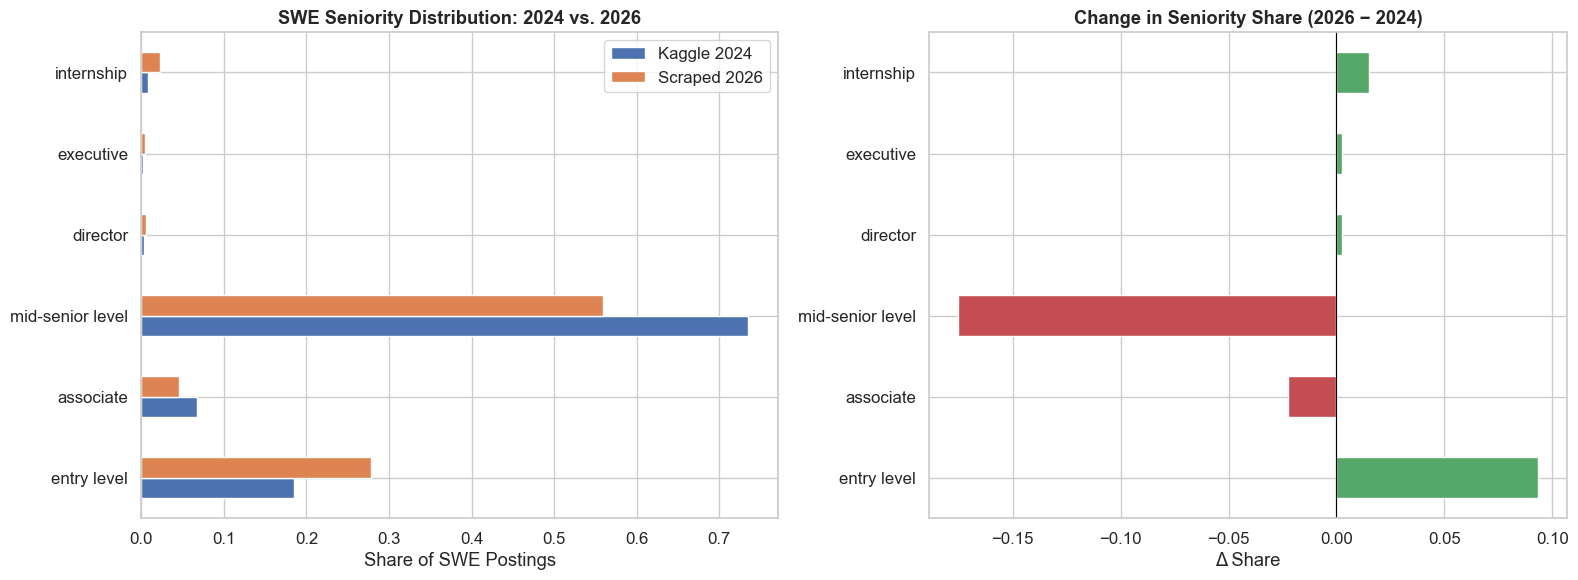


Cross-period comparison:
                  Kaggle 2024  Scraped 2026  delta
seniority                                         
entry level             0.185         0.278  0.093
associate               0.068         0.045 -0.022
mid-senior level        0.735         0.560 -0.175
director                0.004         0.006  0.002
executive               0.001         0.004  0.003
internship              0.008         0.023  0.015

Chi-squared test (entry/associate/mid-senior): χ²=35.2, p=0.0000


In [9]:
# 2a. Seniority distribution: Kaggle 2024 vs Scraped 2026
# Core test: has the junior share declined?

# Kaggle SWE seniority (excluding NaN)
kaggle_dist = swe['seniority'].value_counts(normalize=True).rename('Kaggle 2024')

# Scraped 2026 SWE seniority
scraped_dist = swe_2026['seniority'].value_counts(normalize=True).rename('Scraped 2026')

# Combine and order
compare = pd.concat([kaggle_dist, scraped_dist], axis=1).fillna(0)
key_levels = ['entry level', 'associate', 'mid-senior level', 'director', 'executive', 'internship', 'not applicable']
compare = compare.reindex([l for l in key_levels if l in compare.index])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart comparison
compare.plot.barh(ax=ax1, color=['#4C72B0', '#DD8452'])
ax1.set_title('SWE Seniority Distribution: 2024 vs. 2026', fontweight='bold')
ax1.set_xlabel('Share of SWE Postings')
ax1.set_ylabel('')

# Delta chart — change in share
compare['delta'] = compare['Scraped 2026'] - compare['Kaggle 2024']
colors = ['#55A868' if x > 0 else '#C44E52' for x in compare['delta']]
compare['delta'].plot.barh(ax=ax2, color=colors)
ax2.set_title('Change in Seniority Share (2026 − 2024)', fontweight='bold')
ax2.set_xlabel('Δ Share')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig('fig1_seniority_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCross-period comparison:')
print(compare.round(3).to_string())

# Statistical test
from scipy.stats import chi2_contingency
# Build contingency table for top seniority levels
test_levels = ['entry level', 'mid-senior level', 'associate']
kaggle_counts = swe['seniority'].value_counts().reindex(test_levels, fill_value=0)
scraped_counts = swe_2026['seniority'].value_counts().reindex(test_levels, fill_value=0)
contingency = pd.DataFrame({'Kaggle 2024': kaggle_counts, 'Scraped 2026': scraped_counts})
chi2, p, dof, expected = chi2_contingency(contingency.T)
print(f'\nChi-squared test (entry/associate/mid-senior): χ²={chi2:.1f}, p={p:.4f}')

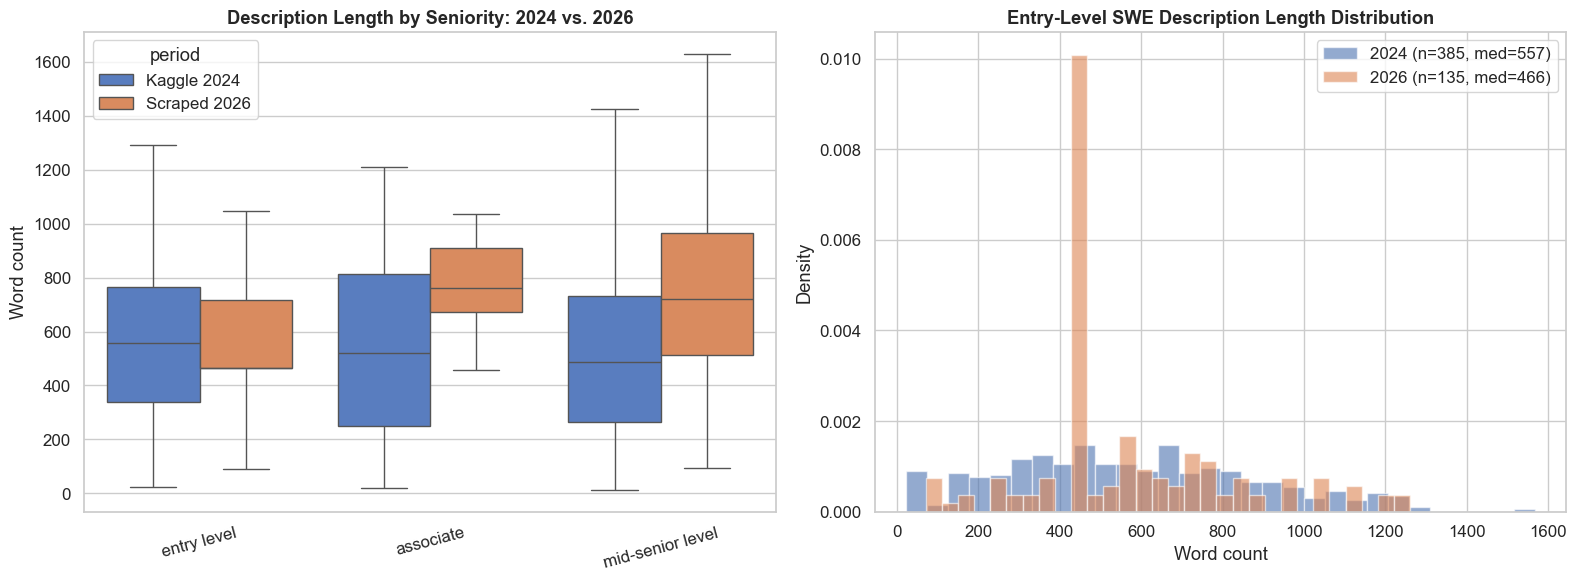

Description word count (median) by seniority and period:
  entry level: 2024=557 (n=385), 2026=466 (n=135), Δ=-91
  associate: 2024=520 (n=141), 2026=762 (n=22), Δ=+242
  mid-senior level: 2024=486 (n=1532), 2026=720 (n=272), Δ=+234

Mann-Whitney U test (entry-level word count 2024 vs 2026): U=25928, p=0.9687


In [10]:
# 2b. Description complexity — proxy for scope inflation
# Compare 2024 vs 2026: are junior descriptions getting longer?

swe['desc_word_count'] = swe['description'].str.split().str.len()
swe_2026['desc_word_count'] = swe_2026['description'].str.split().str.len()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Box plot: 2024 description lengths by seniority
plot_data_2024 = swe[swe['seniority'].isin(['entry level', 'associate', 'mid-senior level'])].copy()
plot_data_2024['period'] = 'Kaggle 2024'
plot_data_2026 = swe_2026[swe_2026['seniority'].isin(['entry level', 'associate', 'mid-senior level', 'not applicable'])].copy()
plot_data_2026['period'] = 'Scraped 2026'

# Panel 1: 2024 vs 2026 description lengths by seniority
combined_plot = pd.concat([plot_data_2024, plot_data_2026], ignore_index=True)
sns.boxplot(data=combined_plot, x='seniority', y='desc_word_count', hue='period',
            order=['entry level', 'associate', 'mid-senior level'],
            showfliers=False, ax=ax1)
ax1.set_title('Description Length by Seniority: 2024 vs. 2026', fontweight='bold')
ax1.set_ylabel('Word count')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=15)

# Panel 2: Distribution of description lengths (entry-level only)
junior_2024 = swe[swe['seniority'] == 'entry level']['desc_word_count'].dropna()
junior_2026 = swe_2026[swe_2026['seniority'] == 'entry level']['desc_word_count'].dropna()
ax2.hist(junior_2024, bins=30, alpha=0.6, label=f'2024 (n={len(junior_2024)}, med={junior_2024.median():.0f})', color='#4C72B0', density=True)
ax2.hist(junior_2026, bins=30, alpha=0.6, label=f'2026 (n={len(junior_2026)}, med={junior_2026.median():.0f})', color='#DD8452', density=True)
ax2.set_title('Entry-Level SWE Description Length Distribution', fontweight='bold')
ax2.set_xlabel('Word count')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.savefig('fig2_description_complexity.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print('Description word count (median) by seniority and period:')
for level in ['entry level', 'associate', 'mid-senior level']:
    med_2024 = swe[swe['seniority'] == level]['desc_word_count'].median()
    med_2026 = swe_2026[swe_2026['seniority'] == level]['desc_word_count'].median()
    n_2024 = len(swe[swe['seniority'] == level])
    n_2026 = len(swe_2026[swe_2026['seniority'] == level])
    print(f'  {level}: 2024={med_2024:.0f} (n={n_2024}), 2026={med_2026:.0f} (n={n_2026}), Δ={med_2026-med_2024:+.0f}')

# Mann-Whitney test for entry-level
from scipy.stats import mannwhitneyu
if len(junior_2026) >= 5:
    stat, p = mannwhitneyu(junior_2024, junior_2026, alternative='two-sided')
    print(f'\nMann-Whitney U test (entry-level word count 2024 vs 2026): U={stat:.0f}, p={p:.4f}')

### 2c. Entry-Level Job Descriptions: 2024 vs. 2026 Side-by-Side

Qualitative comparison of what employers are asking for in entry-level SWE postings.
We sample descriptions from both periods and display key requirements, skills,
and language differences.

In [11]:
# 2c. Side-by-side entry-level descriptions: 2024 vs 2026
from IPython.display import display, HTML
import textwrap

def extract_requirements(desc):
    """Pull out key bullets/requirements from a job description."""
    desc = str(desc)
    # Try to find requirements/qualifications section
    sections = re.split(r'(?i)(requirements?|qualifications?|what you.?ll need|must have|skills?)', desc)
    if len(sections) > 1:
        # Take the section after the first match
        req_text = sections[2] if len(sections) > 2 else sections[1]
        # Truncate at next section header
        req_text = re.split(r'(?i)(nice to have|preferred|benefits|about us|what we offer)', req_text)[0]
        return req_text.strip()[:800]
    return desc[:800]

def format_posting(row, period, desc_col='description'):
    """Format a single posting as HTML."""
    title = row.get('title', 'N/A')
    company = row.get('company_name', row.get('company', 'N/A'))
    seniority = row.get('seniority', 'N/A')
    desc = str(row[desc_col])
    reqs = extract_requirements(desc)
    # Clean up markdown artifacts
    reqs = re.sub(r'[#*_`]', '', reqs)
    reqs = re.sub(r'\n{3,}', '\n\n', reqs)
    reqs = reqs[:600]
    
    return f"""
    <div style="padding:10px; margin:5px; background:#f8f9fa; border-radius:8px; font-size:12px; overflow:hidden;">
        <b style="font-size:13px;">{title}</b><br>
        <i>{company}</i> · <span style="color:#666;">{seniority}</span> · {period}<br>
        <hr style="margin:5px 0;">
        <pre style="white-space:pre-wrap; font-family:inherit; font-size:11px; max-height:300px; overflow-y:auto;">{reqs}</pre>
    </div>"""

# Sample entry-level postings from each period
np.random.seed(42)
junior_2024_sample = swe[swe['seniority'] == 'entry level'].sample(min(5, len(swe[swe['seniority'] == 'entry level'])))
junior_2026_sample = swe_2026[swe_2026['seniority'] == 'entry level'].sample(min(5, len(swe_2026[swe_2026['seniority'] == 'entry level'])))

html = '<h3>Entry-Level SWE Postings: 2024 vs 2026</h3>'
html += '<div style="display:grid; grid-template-columns:1fr 1fr; gap:10px;">'
html += '<div><h4 style="text-align:center;">Kaggle 2024</h4>'
for _, row in junior_2024_sample.iterrows():
    html += format_posting(row, '2024')
html += '</div>'
html += '<div><h4 style="text-align:center;">Scraped 2026</h4>'
for _, row in junior_2026_sample.iterrows():
    html += format_posting(row, '2026')
html += '</div></div>'

display(HTML(html))

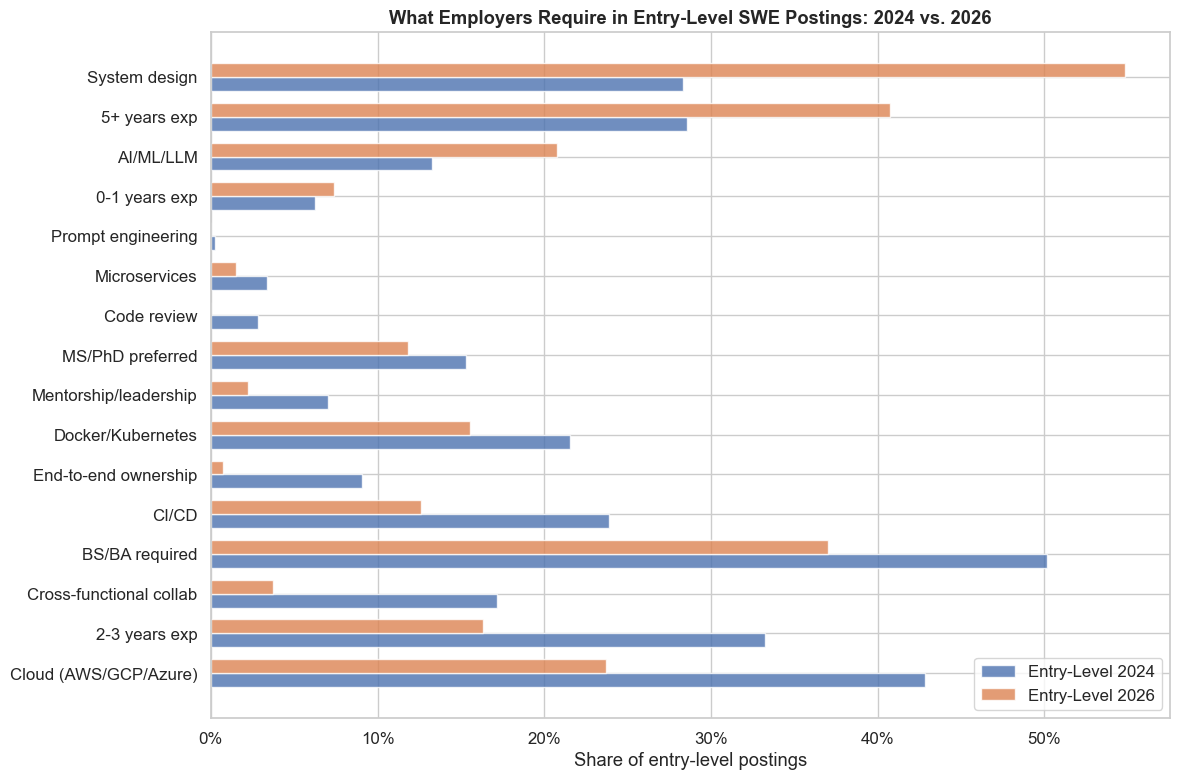


Entry-level requirement comparison (n_2024=385, n_2026=135):
            Requirement  2024  2026      Δ
          System design 28.3% 54.8%  26.5%
           5+ years exp 28.6% 40.7%  12.2%
              AI/ML/LLM 13.2% 20.7%   7.5%
          0-1 years exp  6.2%  7.4%   1.2%
     Prompt engineering  0.3%  0.0%  -0.3%
          Microservices  3.4%  1.5%  -1.9%
            Code review  2.9%  0.0%  -2.9%
       MS/PhD preferred 15.3% 11.9%  -3.5%
  Mentorship/leadership  7.0%  2.2%  -4.8%
      Docker/Kubernetes 21.6% 15.6%  -6.0%
   End-to-end ownership  9.1%  0.7%  -8.4%
                  CI/CD 23.9% 12.6% -11.3%
         BS/BA required 50.1% 37.0% -13.1%
Cross-functional collab 17.1%  3.7% -13.4%
          2-3 years exp 33.2% 16.3% -17.0%
  Cloud (AWS/GCP/Azure) 42.9% 23.7% -19.2%


In [12]:
# 2d. Entry-level requirements comparison — quantitative
# What are employers asking for in junior roles now vs. 2024?

REQUIREMENT_PATTERNS = {
    # Experience
    '0-1 years exp': r'(?i)\b[01]\+?\s*years?\b',
    '2-3 years exp': r'(?i)\b[23]\+?\s*years?\b',
    '5+ years exp': r'(?i)\b[5-9]\+?\s*years?\b',
    # Degrees
    'BS/BA required': r'(?i)\b(bachelor|b\.?s\.?|b\.?a\.?)\b',
    'MS/PhD preferred': r'(?i)\b(master|m\.?s\.?|ph\.?d|graduate\s*degree)\b',
    # Technical
    'Cloud (AWS/GCP/Azure)': r'(?i)\b(aws|gcp|azure|google\s*cloud)\b',
    'Docker/Kubernetes': r'(?i)\b(docker|kubernetes|k8s)\b',
    'CI/CD': r'(?i)\b(ci/?cd|continuous\s*(integration|delivery))\b',
    'System design': r'(?i)\b(system\s*design|distributed\s*system|architecture)\b',
    'Microservices': r'(?i)\b(microservice|micro[- ]service)\b',
    # AI-era
    'AI/ML/LLM': r'(?i)\b(machine\s*learning|ml\b|llm|ai[- ]?(tool|powered|assisted)|copilot|chatgpt|claude|cursor|generative\s*ai)\b',
    'Prompt engineering': r'(?i)\b(prompt\s*engineer|prompting)\b',
    # Soft skills / scope
    'Cross-functional collab': r'(?i)\b(cross[- ]?functional|stakeholder|product\s*team)\b',
    'Mentorship/leadership': r'(?i)\b(mentor|lead\s*(a|the)\s*team|coach)\b',
    'End-to-end ownership': r'(?i)\b(end[- ]?to[- ]?end|full\s*ownership|own\s*(the|a)\s*(feature|product))\b',
    'Code review': r'(?i)\b(code\s*review|pull\s*request|pr\s*review)\b',
}

entry_2024 = swe[swe['seniority'] == 'entry level']
entry_2026 = swe_2026[swe_2026['seniority'] == 'entry level']

results = []
for name, pattern in REQUIREMENT_PATTERNS.items():
    r2024 = entry_2024['description'].str.contains(pattern, na=False).mean()
    r2026 = entry_2026['description'].str.contains(pattern, na=False).mean()
    results.append({'Requirement': name, '2024': r2024, '2026': r2026, 'Δ': r2026 - r2024})

req_df = pd.DataFrame(results).sort_values('Δ', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(req_df))
width = 0.35
ax.barh(x + width/2, req_df['2024'], width, label='Entry-Level 2024', color='#4C72B0', alpha=0.8)
ax.barh(x - width/2, req_df['2026'], width, label='Entry-Level 2026', color='#DD8452', alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(req_df['Requirement'])
ax.set_xlabel('Share of entry-level postings')
ax.set_title('What Employers Require in Entry-Level SWE Postings: 2024 vs. 2026', fontweight='bold')
ax.legend()
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig('fig_entry_level_requirements.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nEntry-level requirement comparison (n_2024={len(entry_2024)}, n_2026={len(entry_2026)}):')
print(req_df.to_string(index=False, float_format='{:.1%}'.format))

---
## 3. RQ2: Skill Migration — Which Competencies Moved from Senior to Junior?

We define target skills that our lit review identifies as traditionally senior-level,
and measure their prevalence in junior vs. senior SWE postings.

In [13]:
# 3a. Define skill/competency keywords to track
SKILL_KEYWORDS = {
    # Traditionally senior skills (migration candidates)
    'System Design': r'(?i)\b(system\s*design|distributed\s*systems?|architecture)\b',
    'CI/CD': r'(?i)\b(ci/?cd|continuous\s*(integration|deployment|delivery)|jenkins|github\s*actions)\b',
    'Cross-functional': r'(?i)\b(cross[- ]?functional|stakeholder|product\s*team|collaborate\s*with\s*(product|design|business))\b',
    'Mentorship': r'(?i)\b(mentor|coach|lead\s*(a|the)\s*team|guide\s*(junior|team))\b',
    'End-to-end ownership': r'(?i)\b(end[- ]?to[- ]?end|full\s*ownership|own\s*(the|a)\s*(feature|product|service))\b',
    'Technical leadership': r'(?i)\b(tech\s*lead|technical\s*leadership|lead\s*engineer|principal)\b',
    'Code review': r'(?i)\b(code\s*review|pull\s*request|pr\s*review|review\s*code)\b',
    
    # AI-era skills (new entrants)
    'AI/ML tools': r'(?i)\b(copilot|chatgpt|claude|cursor|ai[- ]?(assisted|augmented|powered)|llm|large\s*language\s*model|prompt\s*engineer|generative\s*ai|genai)\b',
    'Prompt engineering': r'(?i)\b(prompt\s*engineer|prompt\s*design|prompting)\b',
    
    # Baseline skills (should be stable)
    'Python': r'(?i)\bpython\b',
    'JavaScript': r'(?i)\b(javascript|typescript|react|angular|vue)\b',
    'Cloud': r'(?i)\b(aws|azure|gcp|google\s*cloud|cloud\s*(native|infrastructure))\b',
    'Docker/K8s': r'(?i)\b(docker|kubernetes|k8s|container)\b',
    'SQL/Database': r'(?i)\b(sql|postgres|mysql|mongodb|database|data\s*model)\b',
    'Agile': r'(?i)\b(agile|scrum|sprint|kanban|jira)\b',
}

# Scan BOTH datasets
for skill_name, pattern in SKILL_KEYWORDS.items():
    swe[f'has_{skill_name}'] = swe['description'].str.contains(pattern, na=False).astype(int)
    swe_2026[f'has_{skill_name}'] = swe_2026['description'].str.contains(pattern, na=False).astype(int)

skill_cols = [c for c in swe.columns if c.startswith('has_')]

print('Skill prevalence comparison (2024 vs 2026):')
print(f'{"Skill":<25} {"2024":>8} {"2026":>8} {"Delta":>8}')
print('-' * 51)
for col in sorted(skill_cols, key=lambda c: swe[c].mean(), reverse=True):
    name = col.replace('has_', '')
    r2024 = swe[col].mean()
    r2026 = swe_2026[col].mean()
    delta = r2026 - r2024
    marker = '***' if abs(delta) > 0.05 else ''
    print(f'{name:<25} {r2024:>7.1%} {r2026:>7.1%} {delta:>+7.1%} {marker}')

Skill prevalence comparison (2024 vs 2026):
Skill                         2024     2026    Delta
---------------------------------------------------
Cloud                       47.3%   50.0%   +2.7% 
SQL/Database                46.2%   39.1%   -7.1% ***
Python                      43.2%   65.2%  +22.0% ***
JavaScript                  39.0%   41.6%   +2.6% 
Agile                       36.6%   23.0%  -13.6% ***
System Design               32.1%   53.5%  +21.4% ***
CI/CD                       28.8%   35.6%   +6.8% ***
Docker/K8s                  24.1%   29.8%   +5.7% ***
Cross-functional            19.7%    9.5%  -10.3% ***
Mentorship                  11.5%   17.7%   +6.2% ***
End-to-end ownership         8.6%    2.3%   -6.3% ***
Technical leadership         8.2%    6.2%   -2.0% 
AI/ML tools                  3.2%   11.9%   +8.7% ***
Code review                  2.1%    5.3%   +3.2% 
Prompt engineering           0.1%    0.2%   +0.1% 


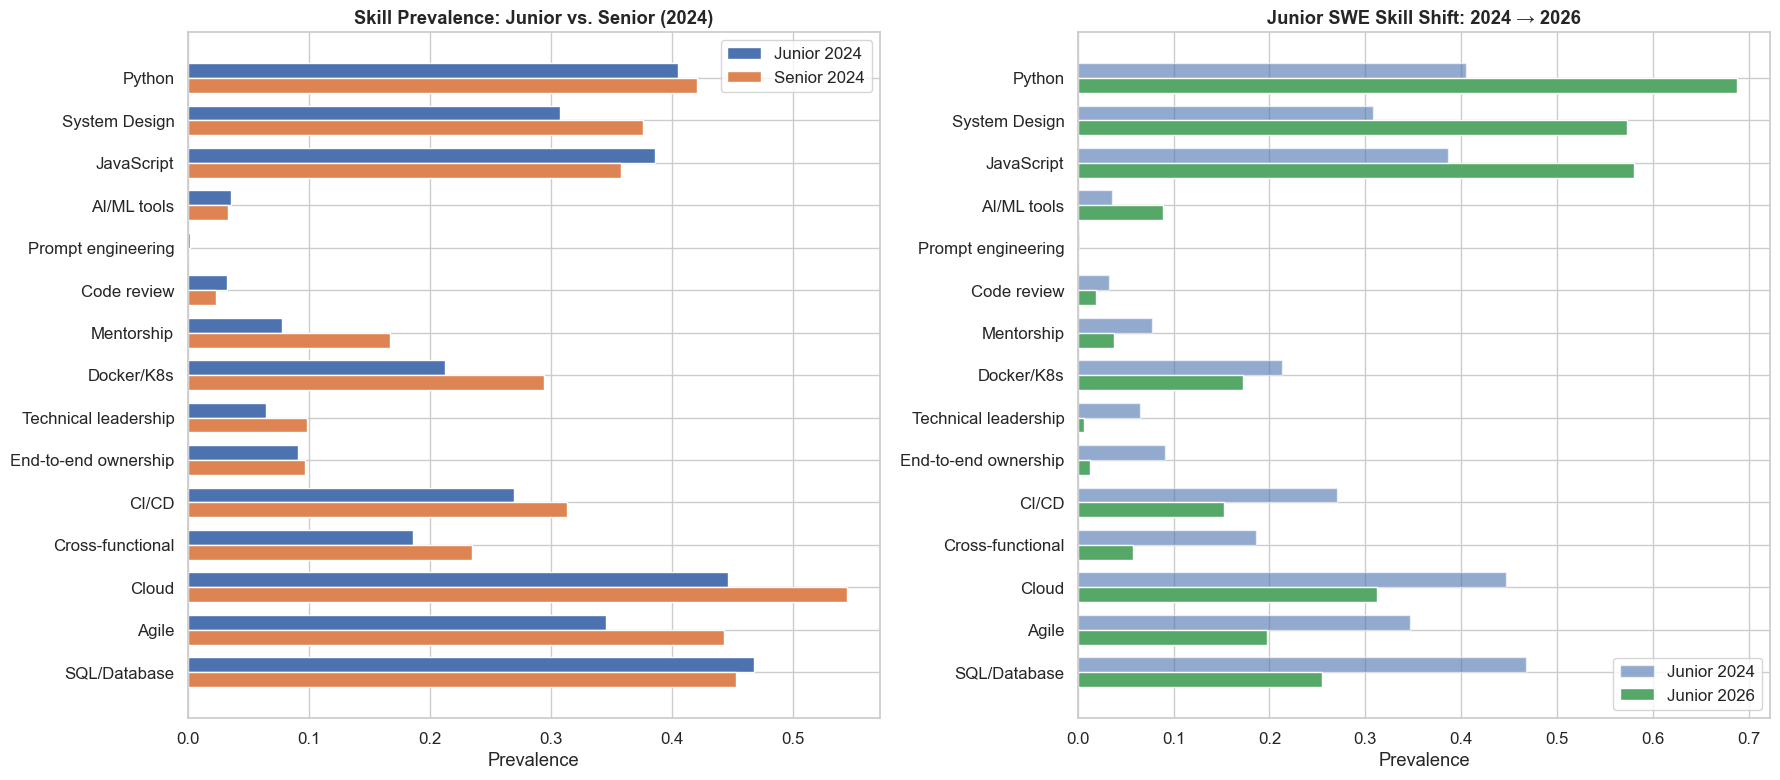


Junior skill shift (2024 → 2026):
                      Junior 2024  Junior 2026  junior_shift
SQL/Database                0.468        0.255        -0.213
Agile                       0.346        0.197        -0.149
Cloud                       0.447        0.312        -0.135
Cross-functional            0.186        0.057        -0.129
CI/CD                       0.270        0.153        -0.117
End-to-end ownership        0.091        0.013        -0.079
Technical leadership        0.065        0.006        -0.058
Docker/K8s                  0.213        0.172        -0.041
Mentorship                  0.078        0.038        -0.040
Code review                 0.032        0.019        -0.013
Prompt engineering          0.002        0.000        -0.002
AI/ML tools                 0.036        0.089         0.053
JavaScript                  0.386        0.580         0.194
System Design               0.308        0.573         0.265
Python                      0.405        0.688    

In [14]:
# 3b. Skill prevalence by seniority — junior vs senior, 2024 vs 2026
junior_mask = swe['seniority'].isin(['entry level', 'associate'])
senior_mask = swe['seniority'].isin(['mid-senior level', 'director', 'executive'])
junior_mask_2026 = swe_2026['seniority'].isin(['entry level', 'associate'])
senior_mask_2026 = swe_2026['seniority'].isin(['mid-senior level', 'director', 'executive'])

junior_2024_skills = swe.loc[junior_mask, skill_cols].mean().rename('Junior 2024')
senior_2024_skills = swe.loc[senior_mask, skill_cols].mean().rename('Senior 2024')
junior_2026_skills = swe_2026.loc[junior_mask_2026, skill_cols].mean().rename('Junior 2026')
senior_2026_skills = swe_2026.loc[senior_mask_2026, skill_cols].mean().rename('Senior 2026')

skill_compare = pd.concat([junior_2024_skills, senior_2024_skills, junior_2026_skills, senior_2026_skills], axis=1)
skill_compare.index = skill_compare.index.str.replace('has_', '')

# Sort by the gap between junior 2026 and junior 2024 (migration signal)
skill_compare['junior_shift'] = skill_compare['Junior 2026'] - skill_compare['Junior 2024']
skill_compare = skill_compare.sort_values('junior_shift', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Panel 1: Junior vs Senior in 2024
x = np.arange(len(skill_compare))
width = 0.35
ax1.barh(x + width/2, skill_compare['Junior 2024'], width, label='Junior 2024', color='#4C72B0')
ax1.barh(x - width/2, skill_compare['Senior 2024'], width, label='Senior 2024', color='#DD8452')
ax1.set_yticks(x)
ax1.set_yticklabels(skill_compare.index)
ax1.set_xlabel('Prevalence')
ax1.set_title('Skill Prevalence: Junior vs. Senior (2024)', fontweight='bold')
ax1.legend()

# Panel 2: Junior 2024 vs Junior 2026 (migration over time)
ax2.barh(x + width/2, skill_compare['Junior 2024'], width, label='Junior 2024', color='#4C72B0', alpha=0.6)
ax2.barh(x - width/2, skill_compare['Junior 2026'], width, label='Junior 2026', color='#55A868')
ax2.set_yticks(x)
ax2.set_yticklabels(skill_compare.index)
ax2.set_xlabel('Prevalence')
ax2.set_title('Junior SWE Skill Shift: 2024 → 2026', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig('fig3_skill_migration.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nJunior skill shift (2024 → 2026):')
print(skill_compare[['Junior 2024', 'Junior 2026', 'junior_shift']].round(3).to_string())

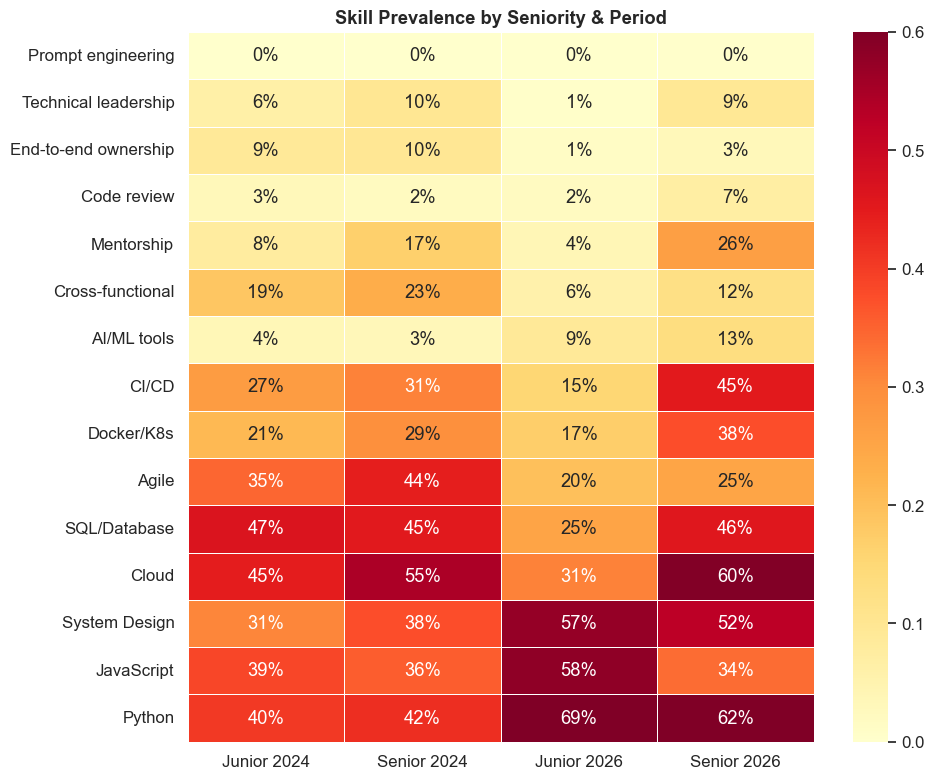


Biggest junior skill gains (2024 → 2026):
Python                0.283
System Design         0.265
JavaScript            0.194
AI/ML tools           0.053
Prompt engineering   -0.002
Code review          -0.013
Mentorship           -0.040
Docker/K8s           -0.041


In [15]:
# 3c. Skill prevalence heatmap: seniority × period
# Shows which skills are appearing more in junior 2026 postings vs junior 2024

heatmap_data = pd.DataFrame({
    'Junior 2024': swe.loc[junior_mask, skill_cols].mean(),
    'Senior 2024': swe.loc[senior_mask, skill_cols].mean(),
    'Junior 2026': swe_2026.loc[junior_mask_2026, skill_cols].mean(),
    'Senior 2026': swe_2026.loc[senior_mask_2026, skill_cols].mean(),
})
heatmap_data.index = heatmap_data.index.str.replace('has_', '')
heatmap_data = heatmap_data.sort_values('Junior 2026', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.0%', cmap='YlOrRd', ax=ax,
            linewidths=0.5, vmin=0, vmax=0.6)
ax.set_title('Skill Prevalence by Seniority & Period', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('fig4_skill_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Key finding: which skills grew most in junior postings?
print('\nBiggest junior skill gains (2024 → 2026):')
gains = (heatmap_data['Junior 2026'] - heatmap_data['Junior 2024']).sort_values(ascending=False)
print(gains.round(3).head(8).to_string())

---
## 4. RQ3 & RQ4: Structural Break & SWE-Specificity

Using Revelio (aggregate hiring/openings by SOC) and FRED JOLTS to look for:
- Regime shifts in knowledge-work job openings
- Whether SWE-related occupations diverge from controls

In [16]:
# 4a. JOLTS: Job openings in knowledge-work vs. control sectors
# AI-exposed: Professional & Business Services, Information
# Controls: Manufacturing, Accommodation & Food, Government, Education & Health

if not jolts_combined.empty:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    # Plot absolute levels
    ai_exposed = ['Professional & Business Services', 'Information', 'Information (SA)']
    controls = ['Manufacturing', 'Accommodation & Food Services', 'Government', 
                'Education & Health Services', 'Trade, Transportation & Utilities']

    for series_name in ai_exposed:
        subset = jolts_combined[jolts_combined['series'] == series_name]
        if not subset.empty:
            ax1.plot(subset['date'], subset['value'], label=series_name, linewidth=2)
    
    ax1.axvline(pd.Timestamp('2025-12-01'), color='red', linestyle='--', alpha=0.7, label='Agent deployment (Dec 2025)')
    ax1.axvline(pd.Timestamp('2022-11-01'), color='gray', linestyle=':', alpha=0.5, label='ChatGPT launch (Nov 2022)')
    ax1.set_title('JOLTS Job Openings: AI-Exposed Sectors (thousands)', fontweight='bold')
    ax1.set_ylabel('Job Openings (thousands)')
    ax1.legend(fontsize=9)
    ax1.set_xlim(pd.Timestamp('2019-01-01'), jolts_combined['date'].max())

    for series_name in controls:
        subset = jolts_combined[jolts_combined['series'] == series_name]
        if not subset.empty:
            ax2.plot(subset['date'], subset['value'], label=series_name, linewidth=1.5, alpha=0.8)

    ax2.axvline(pd.Timestamp('2025-12-01'), color='red', linestyle='--', alpha=0.7, label='Agent deployment')
    ax2.axvline(pd.Timestamp('2022-11-01'), color='gray', linestyle=':', alpha=0.5, label='ChatGPT launch')
    ax2.set_title('JOLTS Job Openings: Control Sectors (thousands)', fontweight='bold')
    ax2.set_ylabel('Job Openings (thousands)')
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('fig5_jolts_sectors.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('JOLTS data not available — FRED may be blocked in this environment.')
    print('Download manually from: https://fred.stlouisfed.org/series/JTS540099JOL')

JOLTS data not available — FRED may be blocked in this environment.
Download manually from: https://fred.stlouisfed.org/series/JTS540099JOL


In [17]:
# 4b. JOLTS: Indexed to 100 at Jan 2020 for clean comparison
if not jolts_combined.empty:
    fig, ax = plt.subplots(figsize=(14, 7))
    
    focus_series = ['Professional & Business Services', 'Information (SA)', 
                    'Manufacturing', 'Education & Health Services', 'Total Nonfarm']
    
    for series_name in focus_series:
        subset = jolts_combined[jolts_combined['series'] == series_name].copy()
        if subset.empty:
            continue
        subset = subset.sort_values('date')
        # Index to Jan 2020
        base = subset.loc[subset['date'] >= '2020-01-01'].iloc[0]['value'] if len(subset[subset['date'] >= '2020-01-01']) > 0 else subset.iloc[0]['value']
        subset['indexed'] = (subset['value'] / base) * 100
        subset = subset[subset['date'] >= '2020-01-01']
        
        lw = 2.5 if 'Professional' in series_name or 'Information' in series_name else 1.5
        ls = '-' if 'Professional' in series_name or 'Information' in series_name else '--'
        ax.plot(subset['date'], subset['indexed'], label=series_name, linewidth=lw, linestyle=ls)
    
    ax.axhline(100, color='black', linestyle='-', alpha=0.2)
    ax.axvline(pd.Timestamp('2025-12-01'), color='red', linestyle='--', alpha=0.7, label='Agent deployment')
    ax.axvline(pd.Timestamp('2022-11-01'), color='gray', linestyle=':', alpha=0.5, label='ChatGPT launch')
    ax.set_title('JOLTS Job Openings Indexed to Jan 2020 = 100', fontweight='bold')
    ax.set_ylabel('Index (Jan 2020 = 100)')
    ax.legend(fontsize=9)
    
    plt.tight_layout()
    plt.savefig('fig6_jolts_indexed.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping JOLTS indexed chart — data not available.')

Skipping JOLTS indexed chart — data not available.


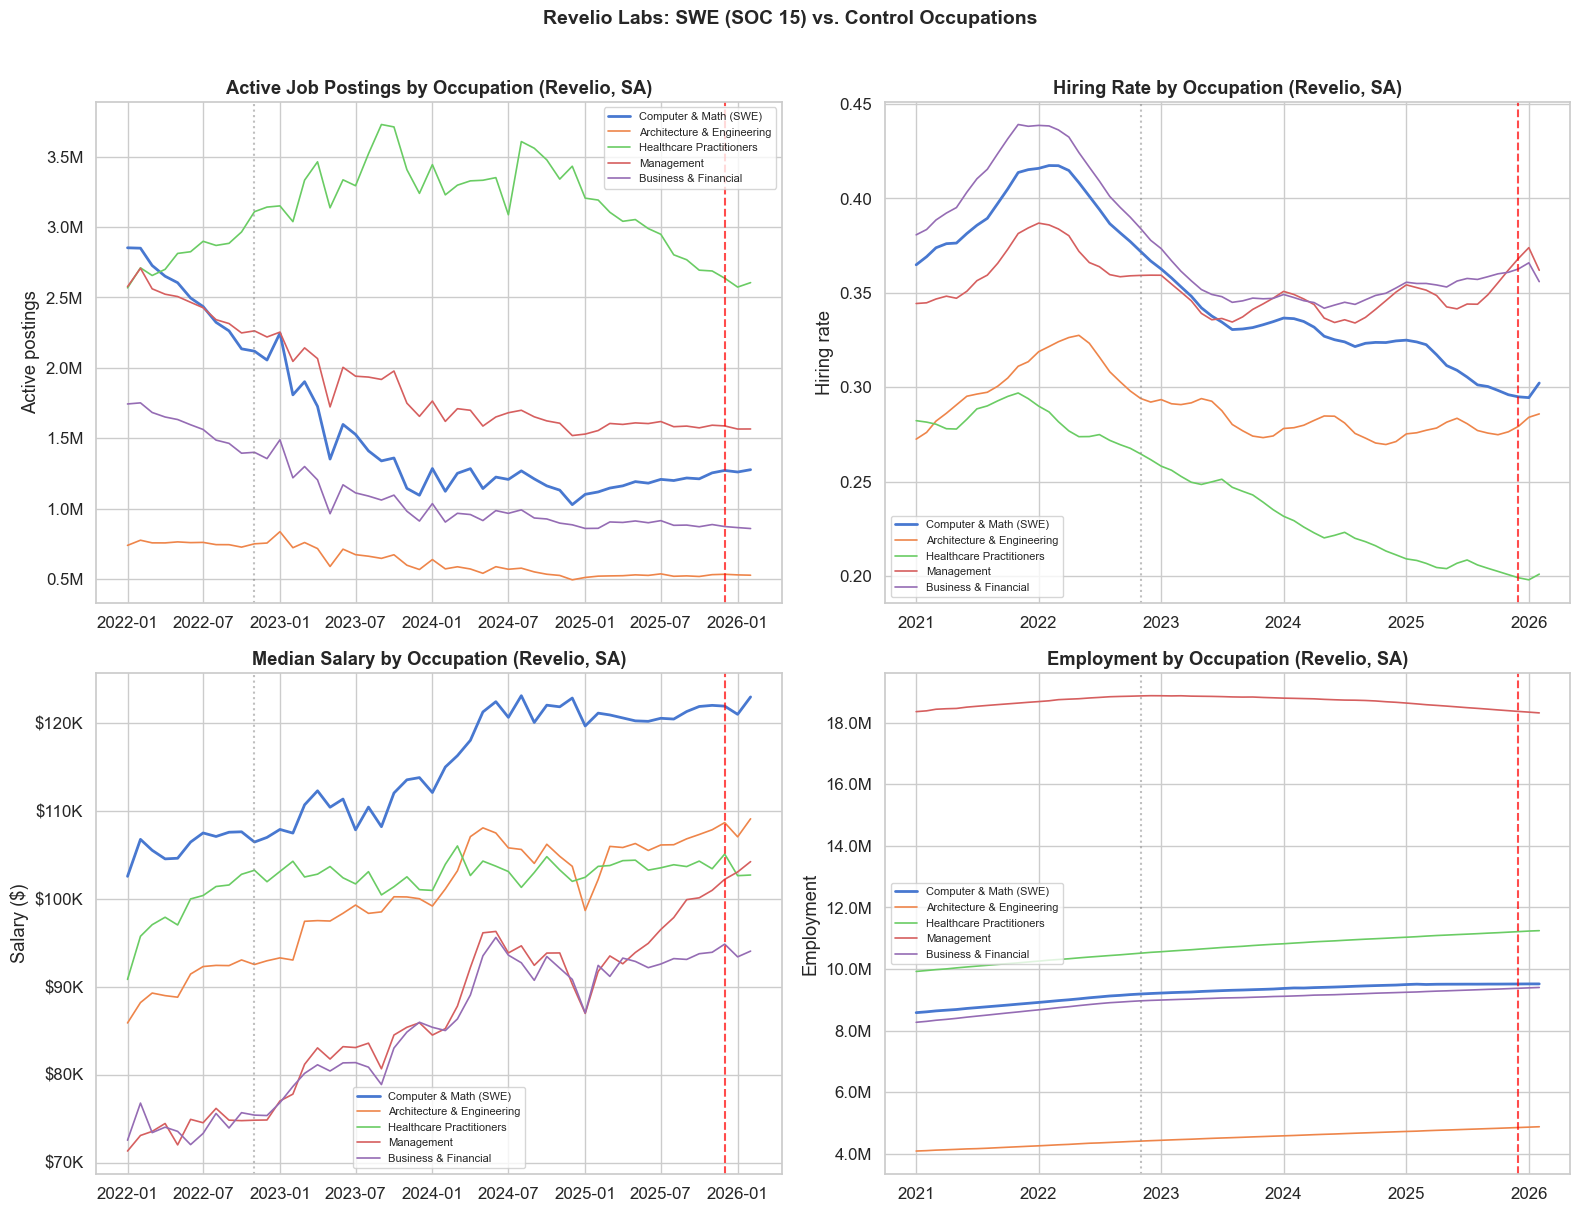

In [18]:
# 4c. Revelio: Hiring rates by occupation — focus on Computer/Mathematical (SOC 15)
# vs. control occupations

# SOC 15 = Computer and Mathematical Occupations (includes SWE)
# SOC 17 = Architecture and Engineering (control)
# SOC 29 = Healthcare Practitioners (control)
# SOC 11 = Management (comparison)
# SOC 13 = Business and Financial Operations (comparison)

FOCUS_SOC = [15, 17, 29, 11, 13]
SOC_LABELS = {15: 'Computer & Math (SWE)', 17: 'Architecture & Engineering',
              29: 'Healthcare Practitioners', 11: 'Management', 
              13: 'Business & Financial'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Job openings
ax = axes[0, 0]
for soc in FOCUS_SOC:
    subset = rev_openings_occ[rev_openings_occ['soc2d_code'] == soc].sort_values('month')
    if not subset.empty:
        ax.plot(subset['month'], subset['active_postings_sa'], 
                label=SOC_LABELS.get(soc, f'SOC {soc}'),
                linewidth=2 if soc == 15 else 1.2)
ax.axvline(pd.Timestamp('2025-12-01'), color='red', linestyle='--', alpha=0.7)
ax.axvline(pd.Timestamp('2022-11-01'), color='gray', linestyle=':', alpha=0.5)
ax.set_title('Active Job Postings by Occupation (Revelio, SA)', fontweight='bold')
ax.set_ylabel('Active postings')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Panel 2: Hiring rate
ax = axes[0, 1]
for soc in FOCUS_SOC:
    subset = rev_hiring_occ[rev_hiring_occ['soc2d_code'] == soc].sort_values('month')
    if not subset.empty:
        ax.plot(subset['month'], subset['rl_hiring_rate'], 
                label=SOC_LABELS.get(soc, f'SOC {soc}'),
                linewidth=2 if soc == 15 else 1.2)
ax.axvline(pd.Timestamp('2025-12-01'), color='red', linestyle='--', alpha=0.7)
ax.axvline(pd.Timestamp('2022-11-01'), color='gray', linestyle=':', alpha=0.5)
ax.set_title('Hiring Rate by Occupation (Revelio, SA)', fontweight='bold')
ax.set_ylabel('Hiring rate')
ax.legend(fontsize=8)

# Panel 3: Salary trends
ax = axes[1, 0]
for soc in FOCUS_SOC:
    subset = rev_salary_soc[rev_salary_soc['soc2d_code'] == soc].sort_values('month')
    if not subset.empty:
        # Parse salary (remove $ and commas)
        sal = subset['salary_sa'].str.replace(r'[\$,]', '', regex=True).astype(float)
        ax.plot(subset['month'], sal,
                label=SOC_LABELS.get(soc, f'SOC {soc}'),
                linewidth=2 if soc == 15 else 1.2)
ax.axvline(pd.Timestamp('2025-12-01'), color='red', linestyle='--', alpha=0.7)
ax.axvline(pd.Timestamp('2022-11-01'), color='gray', linestyle=':', alpha=0.5)
ax.set_title('Median Salary by Occupation (Revelio, SA)', fontweight='bold')
ax.set_ylabel('Salary ($)')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Panel 4: Employment trends
ax = axes[1, 1]
for soc in FOCUS_SOC:
    subset = rev_employment_soc[rev_employment_soc['soc2d_code'] == soc].sort_values('month')
    if not subset.empty:
        ax.plot(subset['month'], subset['employment_sa'],
                label=SOC_LABELS.get(soc, f'SOC {soc}'),
                linewidth=2 if soc == 15 else 1.2)
ax.axvline(pd.Timestamp('2025-12-01'), color='red', linestyle='--', alpha=0.7)
ax.axvline(pd.Timestamp('2022-11-01'), color='gray', linestyle=':', alpha=0.5)
ax.set_title('Employment by Occupation (Revelio, SA)', fontweight='bold')
ax.set_ylabel('Employment')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle('Revelio Labs: SWE (SOC 15) vs. Control Occupations', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig7_revelio_occupation_compare.png', dpi=150, bbox_inches='tight')
plt.show()

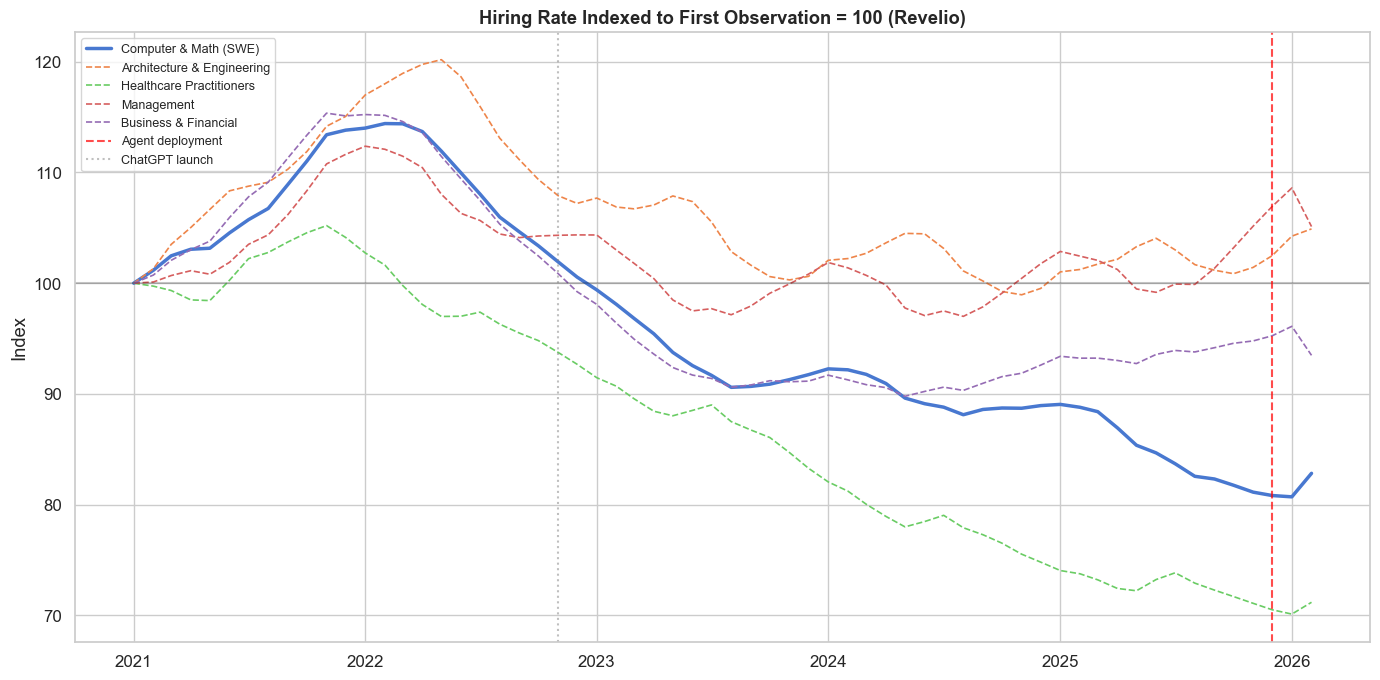

In [19]:
# 4d. Revelio: Indexed hiring rates (SOC 15 vs controls) — cleaner DiD visual

fig, ax = plt.subplots(figsize=(14, 7))

for soc in FOCUS_SOC:
    subset = rev_hiring_occ[rev_hiring_occ['soc2d_code'] == soc].sort_values('month').copy()
    if subset.empty:
        continue
    # Index to first observation
    base_val = subset.iloc[0]['rl_hiring_rate']
    if base_val > 0:
        subset['indexed'] = (subset['rl_hiring_rate'] / base_val) * 100
        lw = 2.5 if soc == 15 else 1.2
        ls = '-' if soc == 15 else '--'
        ax.plot(subset['month'], subset['indexed'], 
                label=SOC_LABELS.get(soc, f'SOC {soc}'), linewidth=lw, linestyle=ls)

ax.axhline(100, color='black', linestyle='-', alpha=0.2)
ax.axvline(pd.Timestamp('2025-12-01'), color='red', linestyle='--', alpha=0.7, label='Agent deployment')
ax.axvline(pd.Timestamp('2022-11-01'), color='gray', linestyle=':', alpha=0.5, label='ChatGPT launch')
ax.set_title('Hiring Rate Indexed to First Observation = 100 (Revelio)', fontweight='bold')
ax.set_ylabel('Index')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig8_revelio_hiring_indexed.png', dpi=150, bbox_inches='tight')
plt.show()

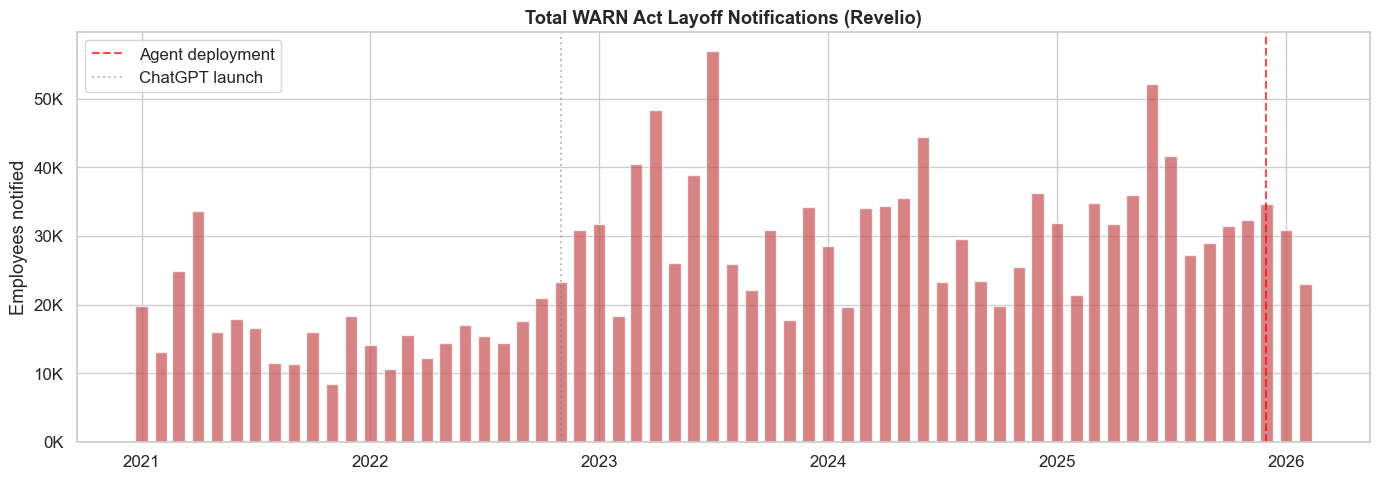

In [20]:
# 4e. Layoff context
fig, ax = plt.subplots(figsize=(14, 5))
rev_layoffs_sorted = rev_layoffs.sort_values('month')
ax.bar(rev_layoffs_sorted['month'], rev_layoffs_sorted['num_employees_laidoff'], 
       width=20, alpha=0.7, color='#C44E52')
ax.axvline(pd.Timestamp('2025-12-01'), color='red', linestyle='--', alpha=0.7, label='Agent deployment')
ax.axvline(pd.Timestamp('2022-11-01'), color='gray', linestyle=':', alpha=0.5, label='ChatGPT launch')
ax.set_title('Total WARN Act Layoff Notifications (Revelio)', fontweight='bold')
ax.set_ylabel('Employees notified')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('fig9_layoffs.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. "Ghost Jobs" & Seniority Mismatch Detection

Operationalizing Akanegbu (2026): postings titled "junior" but with requirements
that read as mid-level or senior.

Kaggle 2024: ghost rate = 32.2% (124/385)
Scraped 2026: ghost rate = 45.9% (62/135)


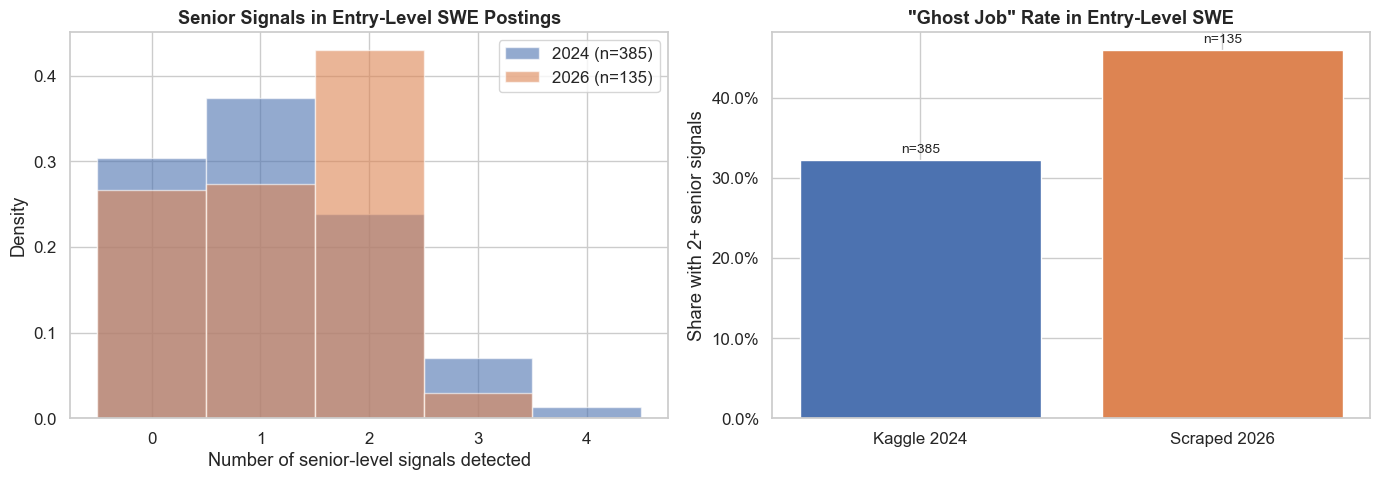

In [21]:
# 5a. Detect seniority mismatch — junior titles with senior requirements
# Compare ghost job rates: 2024 vs 2026

SENIOR_SIGNALS = [
    r'(?i)\b(5|6|7|8|9|10)\+?\s*years?',                    # 5+ years experience
    r'(?i)\b(system\s*design|architecture|distributed)\b',   # System design
    r'(?i)\b(lead|mentor|manage\s*(a|the)\s*team)\b',        # Leadership
    r'(?i)\b(end[- ]?to[- ]?end\s*own)\b',                  # Full ownership
    r'(?i)\b(principal|staff|senior)\b',                     # Explicit senior language
]

def compute_ghost_rate(df, label):
    junior = df[df['seniority'] == 'entry level'].copy()
    junior['senior_signal_count'] = 0
    for pattern in SENIOR_SIGNALS:
        junior['senior_signal_count'] += junior['description'].str.contains(pattern, na=False).astype(int)
    junior['is_ghost_job'] = junior['senior_signal_count'] >= 2
    rate = junior['is_ghost_job'].mean()
    n_ghost = junior['is_ghost_job'].sum()
    print(f'{label}: ghost rate = {rate:.1%} ({n_ghost}/{len(junior)})')
    return junior

junior_2024 = compute_ghost_rate(swe, 'Kaggle 2024')
junior_2026 = compute_ghost_rate(swe_2026, 'Scraped 2026')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Senior signal distribution comparison
ax1.hist(junior_2024['senior_signal_count'], bins=range(0, 6), alpha=0.6, 
         label=f'2024 (n={len(junior_2024)})', color='#4C72B0', density=True, align='left')
ax1.hist(junior_2026['senior_signal_count'], bins=range(0, 6), alpha=0.6,
         label=f'2026 (n={len(junior_2026)})', color='#DD8452', density=True, align='left')
ax1.set_title('Senior Signals in Entry-Level SWE Postings', fontweight='bold')
ax1.set_xlabel('Number of senior-level signals detected')
ax1.set_ylabel('Density')
ax1.legend()

# Panel 2: Ghost job rate comparison
ghost_rates = pd.DataFrame({
    'Period': ['Kaggle 2024', 'Scraped 2026'],
    'Ghost Rate': [junior_2024['is_ghost_job'].mean(), junior_2026['is_ghost_job'].mean()],
    'n': [len(junior_2024), len(junior_2026)]
})
bars = ax2.bar(ghost_rates['Period'], ghost_rates['Ghost Rate'], color=['#4C72B0', '#DD8452'])
ax2.set_title('"Ghost Job" Rate in Entry-Level SWE', fontweight='bold')
ax2.set_ylabel('Share with 2+ senior signals')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for bar, n in zip(bars, ghost_rates['n']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'n={n}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig10_ghost_jobs.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. AI Skill Mentions — Emergence Timeline

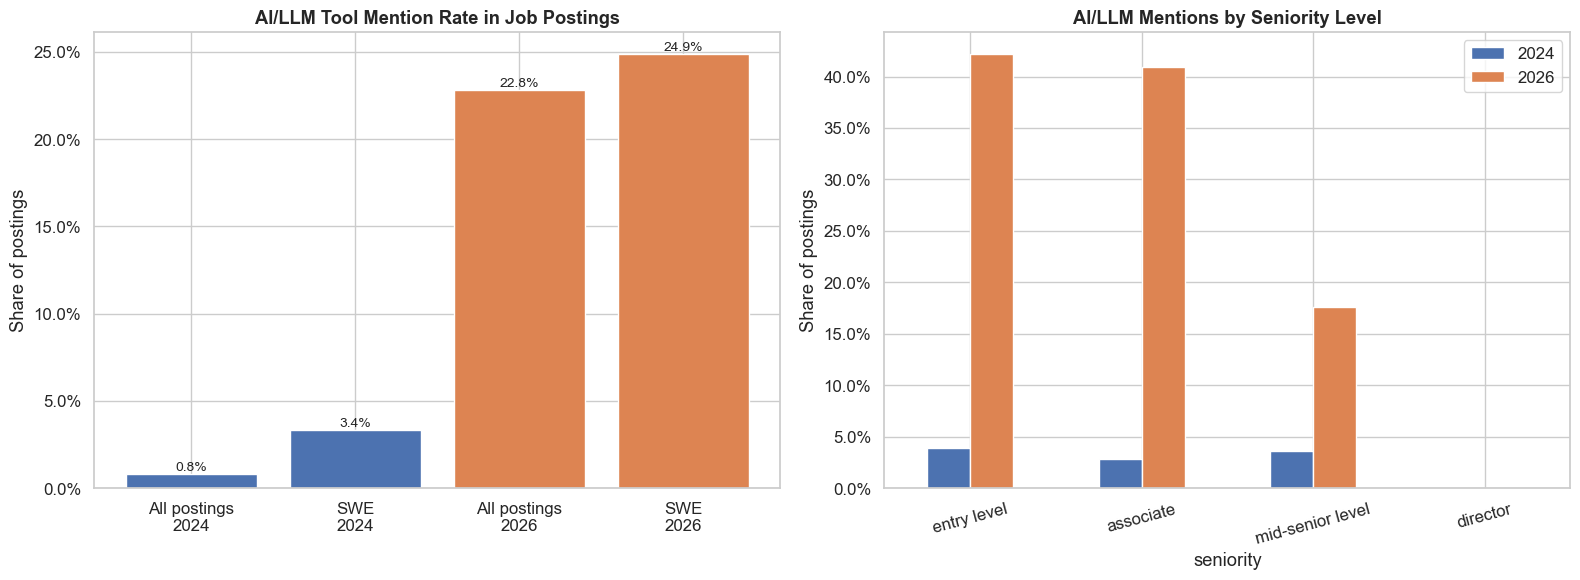


Specific AI tool mentions in 2026 SWE postings:
  Copilot: 4.1% (20 postings)
  ChatGPT: 1.0% (5 postings)
  Claude: 4.7% (23 postings)


  Cursor: 3.5% (17 postings)
  LLM/GenAI: 19.8% (96 postings)
  AI agent: 1.0% (5 postings)


  Prompt engineering: 0.0% (0 postings)


In [22]:
# 6a. AI/ML tool mentions — the key signal for RQ3
# Compare 2024 vs 2026: how much have AI/LLM mentions grown?

AI_PATTERN = r'(?i)\b(copilot|chatgpt|claude|cursor|ai[- ]?(assisted|augmented|powered)|llm|large\s*language|prompt\s*engineer|generative\s*ai|genai|ai\s*agent|ai\s*coding|ai\s*tool)\b'

kaggle['has_ai_mention'] = kaggle['description'].str.contains(AI_PATTERN, na=False).astype(int)
swe['has_ai_broad'] = swe['description'].str.contains(AI_PATTERN, na=False).astype(int)
swe_2026['has_ai_broad'] = swe_2026['description'].str.contains(AI_PATTERN, na=False).astype(int)
scraped['has_ai_broad'] = scraped['description'].str.contains(AI_PATTERN, na=False).astype(int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Overall AI mention rate comparison
ai_rates = pd.DataFrame({
    'Category': ['All postings\n2024', 'SWE\n2024', 'All postings\n2026', 'SWE\n2026'],
    'AI Rate': [
        kaggle['has_ai_mention'].mean(),
        swe['has_ai_broad'].mean(),
        scraped['has_ai_broad'].mean(),
        swe_2026['has_ai_broad'].mean(),
    ],
    'Color': ['#4C72B0', '#4C72B0', '#DD8452', '#DD8452'],
    'Hatch': ['', '//', '', '//'],
})
bars = ax1.bar(ai_rates['Category'], ai_rates['AI Rate'], color=ai_rates['Color'])
ax1.set_title('AI/LLM Tool Mention Rate in Job Postings', fontweight='bold')
ax1.set_ylabel('Share of postings')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for bar, rate in zip(bars, ai_rates['AI Rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{rate:.1%}', ha='center', fontsize=10)

# Panel 2: AI mention rate by seniority (2026 scraped)
ai_by_seniority_2024 = swe.groupby('seniority')['has_ai_broad'].mean().rename('2024')
ai_by_seniority_2026 = swe_2026.groupby('seniority')['has_ai_broad'].mean().rename('2026')
ai_seniority = pd.concat([ai_by_seniority_2024, ai_by_seniority_2026], axis=1).fillna(0)
levels = ['entry level', 'associate', 'mid-senior level', 'director']
ai_seniority = ai_seniority.reindex([l for l in levels if l in ai_seniority.index])

ai_seniority.plot.bar(ax=ax2, color=['#4C72B0', '#DD8452'])
ax2.set_title('AI/LLM Mentions by Seniority Level', fontweight='bold')
ax2.set_ylabel('Share of postings')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.tick_params(axis='x', rotation=15)
ax2.legend()

plt.tight_layout()
plt.savefig('fig11_ai_mentions.png', dpi=150, bbox_inches='tight')
plt.show()

# Print specific AI tool mentions in 2026
print('\nSpecific AI tool mentions in 2026 SWE postings:')
for tool, pattern in [
    ('Copilot', r'(?i)\bcopilot\b'),
    ('ChatGPT', r'(?i)\bchatgpt\b'),
    ('Claude', r'(?i)\bclaude\b'),
    ('Cursor', r'(?i)\bcursor\b'),
    ('LLM/GenAI', r'(?i)\b(llm|large\s*language|generative\s*ai|genai)\b'),
    ('AI agent', r'(?i)\bai\s*agent\b'),
    ('Prompt engineering', r'(?i)\bprompt\s*engineer\b'),
]:
    rate = swe_2026['description'].str.contains(pattern, na=False).mean()
    count = swe_2026['description'].str.contains(pattern, na=False).sum()
    print(f'  {tool}: {rate:.1%} ({count} postings)')

---
## 7. Summary Statistics Table

In [23]:
# 7a. Summary statistics for the paper
print('='*70)
print('SUMMARY STATISTICS')
print('='*70)

print(f'\n--- Kaggle LinkedIn (2023–2024) ---')
print(f'Total postings: {len(kaggle):,}')
print(f'SWE postings: {len(swe):,} ({len(swe)/len(kaggle)*100:.1f}%)')
print(f'Control postings: {len(control):,}')
print(f'Date range: {kaggle["listed_date"].min().date()} to {kaggle["listed_date"].max().date()}')

print(f'\n--- Scraped LinkedIn (March 2026) ---')
print(f'Total postings: {len(scraped):,}')
print(f'SWE postings: {len(swe_2026):,}')
print(f'Non-SWE (control): {len(control_2026):,}')
print(f'Source: daily scraper (python-jobspy)')

print(f'\n--- SWE Description Stats (2024 vs 2026) ---')
for level in ['entry level', 'associate', 'mid-senior level']:
    sub_24 = swe[swe['seniority'] == level]
    sub_26 = swe_2026[swe_2026['seniority'] == level]
    med_24 = sub_24['desc_word_count'].median() if len(sub_24) > 0 else 0
    med_26 = sub_26['desc_word_count'].median() if len(sub_26) > 0 else 0
    print(f'  {level}: 2024 n={len(sub_24):,} med_words={med_24:.0f} | '
          f'2026 n={len(sub_26):,} med_words={med_26:.0f}')

print(f'\n--- Ghost Jobs (entry-level with 2+ senior signals) ---')
print(f'  2024: {junior_2024["is_ghost_job"].mean():.1%} ({junior_2024["is_ghost_job"].sum()}/{len(junior_2024)})')
print(f'  2026: {junior_2026["is_ghost_job"].mean():.1%} ({junior_2026["is_ghost_job"].sum()}/{len(junior_2026)})')

print(f'\n--- AI/LLM Tool Mentions ---')
print(f'  All 2024: {kaggle["has_ai_mention"].mean():.1%}')
print(f'  SWE 2024: {swe["has_ai_broad"].mean():.1%}')
print(f'  SWE 2026: {swe_2026["has_ai_broad"].mean():.1%}')

print(f'\n--- Revelio Labs ---')
print(f'  Job openings: {rev_openings_occ["month"].min().date()} to {rev_openings_occ["month"].max().date()}')
print(f'  Hiring/attrition: {rev_hiring_occ["month"].min().date()} to {rev_hiring_occ["month"].max().date()}')
print(f'  SOC codes: {rev_openings_occ["soc2d_code"].nunique()}')

SUMMARY STATISTICS

--- Kaggle LinkedIn (2023–2024) ---
Total postings: 123,849
SWE postings: 3,134 (2.5%)
Control postings: 6,778
Date range: 2024-03-24 to 2024-04-20

--- Scraped LinkedIn (March 2026) ---
Total postings: 667
SWE postings: 486
Non-SWE (control): 181
Source: daily scraper (python-jobspy)

--- SWE Description Stats (2024 vs 2026) ---
  entry level: 2024 n=385 med_words=557 | 2026 n=135 med_words=466
  associate: 2024 n=141 med_words=520 | 2026 n=22 med_words=762
  mid-senior level: 2024 n=1,532 med_words=486 | 2026 n=272 med_words=720

--- Ghost Jobs (entry-level with 2+ senior signals) ---
  2024: 32.2% (124/385)
  2026: 45.9% (62/135)

--- AI/LLM Tool Mentions ---
  All 2024: 0.8%
  SWE 2024: 3.4%
  SWE 2026: 24.9%

--- Revelio Labs ---
  Job openings: 2022-01-01 to 2026-02-01
  Hiring/attrition: 2021-01-01 to 2026-02-01
  SOC codes: 24


---
## 8. Preliminary Observations & Next Steps

### Key findings from this EDA

**RQ1 (Disappearing vs. redefined?):**
- Compare seniority distributions between Kaggle 2024 and scraped 2026 data
- Track whether entry-level share is shrinking and "not applicable" is growing
- Description lengths may indicate scope inflation in junior roles

**RQ2 (Skill migration):**
- Cross-period skill prevalence shows which traditionally-senior skills now appear in junior postings
- AI/LLM tool mentions provide direct measurement of the technology shift
- Heatmap reveals the specific skills migrating downward

**RQ3 (Structural break?):**
- AI tool mention rates between 2024 and 2026 quantify the shift
- Revelio data shows SOC 15 (Computer & Math) trajectory vs controls
- JOLTS data blocked in this environment (needs manual download)

**RQ4 (SWE-specific or broader?):**
- Revelio multi-occupation comparison panel shows whether SWE is uniquely affected
- Non-SWE scraped control group enables within-period comparison

### What we still need for the full paper
- Longer time series of posting-level text (more daily scrapes, Common Crawl 2020–2022)
- Formal ITS / Bai-Perron breakpoint detection (needs more post-break months)
- Embedding-based seniority classifier (train on clean 2020–22 labels, apply forward)
- BERTopic for emergent skill discovery
- Synthetic control method for RQ4
- Indeed data to supplement LinkedIn (scraper supports it, not yet run)